# 🧪 Lab 1 — Pandas, Statistics & Plotting from Zero
**Goal:** by the end of this notebook you can load a dataset, explore it, filter it, summarize it with statistics, and visualize it — the core toolkit of every data analyst.

**How to use this notebook:** run each cell with **Shift+Enter**, top to bottom. Cells marked **✏️ YOUR TURN** are for you — replace the `...` with your own code. Most answers are 1–3 lines.

**Connection to Andrew's course:** there you worked with NumPy arrays (your `X` matrix and `y` vector). **pandas** is built on top of NumPy — think of a DataFrame as a NumPy matrix with named columns, like a smart Excel sheet inside Python. Everything you learn here feeds directly into the modelling work later.

**How you'll be assessed:** the numbered exercises (code) and the 🏆 business questions at the end (numbers + chart + a written answer in plain English). A correct number with no explanation is a half answer.

In [2]:
# SETUP — always the first cell of any notebook
import pandas as pd        # tables (DataFrames)
import numpy as np         # numbers/arrays (you know this one!)
import matplotlib.pyplot as plt   # plotting
import seaborn as sns      # prettier statistical plotting, built on matplotlib
sns.set_theme()            # nicer default style
print("pandas version:", pd.__version__)

pandas version: 2.1.4


## 1. What is a DataFrame?
A **DataFrame** is a table: rows = observations (one row = one thing), columns = features of that thing. Let's build a tiny one by hand from a dictionary.

In [3]:
students = pd.DataFrame({
    "name":  ["Omar", "Sara", "Youssef", "Nour", "Ali"],
    "age":   [21, 22, 20, 23, 21],
    "city":  ["Cairo", "Giza", "Alexandria", "Cairo", "Giza"],
    "score": [85, 92, 78, 95, 88],
})
students   # the last line of a cell gets displayed automatically

,name,age,city,score
0,Omar,21,Cairo,85
1,Sara,22,Giza,92
2,Youssef,20,Alexandria,78
3,Nour,23,Cairo,95
4,Ali,21,Giza,88


In [4]:
# The anatomy of a DataFrame:
print("shape (rows, columns):", students.shape)
print("columns:", list(students.columns))
print("column types:\n", students.dtypes)

shape (rows, columns): (5, 4)
columns: ['name', 'age', 'city', 'score']
column types:
 name     object
age       int64
city     object
score     int64
dtype: object


In [5]:
# ✏️ YOUR TURN — Exercise 1
# Build a DataFrame called `foods` with 3 rows and columns: "food", "price", "rating" (1-10).
# Use any foods you like. Then display it.
food = pd.DataFrame({"food": ["koshary" , "pizza" , "Burger"],
                     "price" : [5 , 190 , 150] , 
                     "rating" : [10 , 7.5 , 4]})

print(food)

      food  price  rating
0  koshary      5    10.0
1    pizza    190     7.5
2   Burger    150     4.0


In [6]:
# ✏️ YOUR TURN — Exercise 1b
# From your `foods` table, print ONLY the food with the highest rating.
# (hint: .sort_values(...) then .head(1), or use a filter)
food[food["rating"] == food["rating"].max()]

,food,price,rating
0,koshary,5,10.0


## 2. Loading a real dataset
Real data comes from files (usually CSV). We'll use the famous **tips** dataset: **each row = one meal served at a restaurant**, with the bill, the tip, and info about the table.

| column | meaning |
|---|---|
| total_bill | bill in dollars |
| tip | tip in dollars |
| sex | who paid |
| smoker | smoking table? |
| day | Thur / Fri / Sat / Sun |
| time | Lunch / Dinner |
| size | number of people |

In [7]:
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
try:
    tips = pd.read_csv(URL)          # read_csv = THE most used pandas function
except Exception:
    tips = sns.load_dataset("tips")  # backup source, same data
print("loaded", tips.shape[0], "meals")

loaded 244 meals


### The first-look ritual 📌
Every time you load ANY dataset, run these four, in this order: `.head()`, `.shape`, `.info()`, `.describe()`. Never skip this — it's how you catch problems early.

In [8]:
tips.head()      # first 5 rows — what does the data LOOK like?

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [9]:
tips.info()      # column types + missing values count. 'object' means text.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [10]:
tips.describe()  # summary statistics for every numeric column

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [11]:
# ✏️ YOUR TURN — Exercise 2
# a) Show the LAST 3 rows of tips  (hint: .tail())
# b) Print how many rows and columns tips has
# c) Using .describe() above, what is the LARGEST total_bill? Type it as a comment.
print(tips[-1:-4:-1]) #a

print("########################")

c =list(tips.columns)
print("columns" ,len(c),"rows", tips.size)

print("########################")

tips["total_bill"].describe() #50.81
# tips["total_bill"].max()

     total_bill   tip     sex smoker   day    time  size
243       18.78  3.00  Female     No  Thur  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
########################
columns 7 rows 1708
########################


count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

In [12]:
# ✏️ YOUR TURN — Exercise 2b
# Looking at .info(): does this dataset have any missing values at all?
# Answer as a comment, and say which single command told you.
tips.info() ## no nulls
tips.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## 3. Selecting columns
- `tips["tip"]` → ONE column (a **Series**)
- `tips[["total_bill", "tip"]]` → several columns (a smaller **DataFrame** — note the double brackets!)

In [13]:
tips["tip"].head()          # a Series: one column + the index

0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

In [14]:
tips[["total_bill", "tip", "day"]].head()   # double brackets -> DataFrame

,total_bill,tip,day
0,16.99,1.01,Sun
1,10.34,1.66,Sun
2,21.01,3.50,Sun
3,23.68,3.31,Sun
4,24.59,3.61,Sun


In [15]:
# ✏️ YOUR TURN — Exercise 3
# a) Select the "size" column and show its first 5 values
# b) Select "day", "time" and "total_bill" together (one line)
print(tips["size"][:5])
print(tips["size"].head(5))

tips[["day" , "time" , "total_bill"]]

0    2
1    3
2    3
3    2
4    4
Name: size, dtype: int64
0    2
1    3
2    3
3    2
4    4
Name: size, dtype: int64


,day,time,total_bill
0,Sun,Dinner,16.99
1,Sun,Dinner,10.34
2,Sun,Dinner,21.01
3,Sun,Dinner,23.68
4,Sun,Dinner,24.59
...,...,...,...
239,Sat,Dinner,29.03
240,Sat,Dinner,27.18
241,Sat,Dinner,22.67
242,Sat,Dinner,17.82


## 4. Filtering rows — asking questions with conditions
`tips[condition]` keeps only rows where the condition is True. Combine conditions with `&` (and) / `|` (or) — **each condition in its own parentheses**.

In [16]:
big_bills = tips[tips["total_bill"] > 40]
big_bills

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
95,40.17,4.73,Male,Yes,Fri,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


In [17]:
# AND: generous tips at smoking tables
tips[(tips["tip"] > 5) & (tips["smoker"] == "Yes")]

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
172,7.25,5.15,Male,Yes,Sun,Dinner,2
181,23.33,5.65,Male,Yes,Sun,Dinner,2
183,23.17,6.50,Male,Yes,Sun,Dinner,4
211,25.89,5.16,Male,Yes,Sat,Dinner,4
214,28.17,6.50,Female,Yes,Sat,Dinner,3


In [18]:
# .isin() = "is one of these values"
weekend = tips[tips["day"].isin(["Sat", "Sun"])]
print("weekend meals:", len(weekend), "out of", len(tips))

weekend meals: 163 out of 244


In [19]:
# ✏️ YOUR TURN — Exercise 4
# a) Keep only Dinner meals. How many are there?
# b) Keep tables with 5 or more people
# c) Lunch meals where the tip was above 4 dollars (two conditions!)
print(tips[tips["time"] == "Dinner"].shape[0])

print(tips[tips["size"] >= 5])

print(tips[(tips["tip"] > 4 ) & (tips["time"] == "Lunch") ])

176
     total_bill   tip     sex smoker   day    time  size
125       29.80  4.20  Female     No  Thur   Lunch     6
141       34.30  6.70    Male     No  Thur   Lunch     6
142       41.19  5.00    Male     No  Thur   Lunch     5
143       27.05  5.00  Female     No  Thur   Lunch     6
155       29.85  5.14  Female     No   Sun  Dinner     5
156       48.17  5.00    Male     No   Sun  Dinner     6
185       20.69  5.00    Male     No   Sun  Dinner     5
187       30.46  2.00    Male    Yes   Sun  Dinner     5
216       28.15  3.00    Male    Yes   Sat  Dinner     5
     total_bill   tip     sex smoker   day   time  size
83        32.68  5.00    Male    Yes  Thur  Lunch     2
85        34.83  5.17  Female     No  Thur  Lunch     4
88        24.71  5.85    Male     No  Thur  Lunch     2
125       29.80  4.20  Female     No  Thur  Lunch     6
141       34.30  6.70    Male     No  Thur  Lunch     6
142       41.19  5.00    Male     No  Thur  Lunch     5
143       27.05  5.00  Female     

In [20]:
# ✏️ YOUR TURN — Exercise 4b
# d) Meals that were EITHER on Friday OR at a table of 6+ people (use | )
# e) Weekend meals where the bill was below the overall median bill (combine a filter with .median())
print(tips[(tips["day"] == "Fri") |(tips["size"] > 6)])
print(tips[(tips["day"].isin(weekend))|(tips["total_bill"] > tips["total_bill"].median())])

     total_bill   tip     sex smoker  day    time  size
90        28.97  3.00    Male    Yes  Fri  Dinner     2
91        22.49  3.50    Male     No  Fri  Dinner     2
92         5.75  1.00  Female    Yes  Fri  Dinner     2
93        16.32  4.30  Female    Yes  Fri  Dinner     2
94        22.75  3.25  Female     No  Fri  Dinner     2
95        40.17  4.73    Male    Yes  Fri  Dinner     4
96        27.28  4.00    Male    Yes  Fri  Dinner     2
97        12.03  1.50    Male    Yes  Fri  Dinner     2
98        21.01  3.00    Male    Yes  Fri  Dinner     2
99        12.46  1.50    Male     No  Fri  Dinner     2
100       11.35  2.50  Female    Yes  Fri  Dinner     2
101       15.38  3.00  Female    Yes  Fri  Dinner     2
220       12.16  2.20    Male    Yes  Fri   Lunch     2
221       13.42  3.48  Female    Yes  Fri   Lunch     2
222        8.58  1.92    Male    Yes  Fri   Lunch     1
223       15.98  3.00  Female     No  Fri   Lunch     3
224       13.42  1.58    Male    Yes  Fri   Lunc

## 5. Sorting and counting categories
- `.sort_values("col", ascending=False)` → order rows
- `.value_counts()` → how many times each category appears (add `normalize=True` for percentages)

In [21]:
tips.sort_values("total_bill", ascending=False).head(5)   # top 5 biggest bills

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3


In [22]:
print(tips["day"].value_counts())
print()
print(tips["day"].value_counts(normalize=True).round(3) * 100)  # as percentages

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

day
Sat     35.7
Sun     31.1
Thur    25.4
Fri      7.8
Name: proportion, dtype: float64


In [23]:
# ✏️ YOUR TURN — Exercise 5
# a) Show the 3 meals with the LARGEST tip
# b) What percentage of meals are at smoker tables? (value_counts with normalize)
print(tips.sort_values("tip", ascending=False)[:3])

tips["smoker"].value_counts(normalize=True) * 100

     total_bill    tip   sex smoker  day    time  size
170       50.81  10.00  Male    Yes  Sat  Dinner     3
212       48.33   9.00  Male     No  Sat  Dinner     4
23        39.42   7.58  Male     No  Sat  Dinner     4


smoker
No     61.885246
Yes    38.114754
Name: proportion, dtype: float64

In [24]:
# ✏️ YOUR TURN — Exercise 5b
# c) How many meals happened at each (day, time) combination?
#    (hint: value_counts works on two columns: tips[["day","time"]].value_counts())
# d) Which combination is the rarest? Write it as a comment.
tips[["day","time"]].value_counts()

## thur dinner

day   time  
Sat   Dinner    87
Sun   Dinner    76
Thur  Lunch     61
Fri   Dinner    12
      Lunch      7
Thur  Dinner     1
Name: count, dtype: int64

## 6. Creating new columns (feature engineering begins here!)
You met this idea in the course as *feature engineering* — building better inputs. In pandas it's one line: `df["new"] = <formula using other columns>`.

In [25]:
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100     # tip as % of the bill
tips["per_person"] = tips["total_bill"] / tips["size"]        # bill per person
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,6.147500


### ⚠️ Dirty numbers: when a numeric column is secretly text
Extremely common in real exports: a column *should* be numeric but `.info()` says `object`, because some cells contain text or blanks. The fix: `pd.to_numeric(col, errors="coerce")` — converts what it can, turns the broken values into `NaN` (missing). **Remember this one.**

In [26]:
dirty = pd.DataFrame({"charges": ["100.5", "230", " ", "abc", "78.9"]})
print("before:", dirty["charges"].dtype)
dirty["charges"] = pd.to_numeric(dirty["charges"], errors="coerce")
print("after: ", dirty["charges"].dtype)
dirty

before: object
after:  float64


,charges
0,100.5
1,230.0
2,NaN
3,NaN
4,78.9


In [27]:
# ✏️ YOUR TURN — Exercise 6
# Create a column "bill_with_tip" = total_bill + tip, then show the mean of that column.
(tips["bill_with_tip"])= (tips["total_bill"]) + (tips["tip"])
tips

,total_bill,tip,sex,smoker,day,time,size,tip_pct,per_person,bill_with_tip
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,8.495000,18.00
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,3.446667,12.00
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,7.003333,24.51
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,11.840000,26.99
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,6.147500,28.20
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697,9.676667,34.95
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352,13.590000,29.18
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232,11.335000,24.67
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426,8.910000,19.57


In [28]:
# ✏️ YOUR TURN — Exercise 6b
# a) Create "is_big_table" = True when size >= 4, else False  (a comparison returns booleans directly)
# b) What PERCENTAGE of meals are big tables? (hint: the mean of a True/False column is the rate!)
# c) In one comment, explain why the mean of a 0/1 (or True/False) column equals a rate.
tips["is_big_table"] =  tips["size"] >= 4
tips

print(tips["is_big_table"].value_counts(normalize=True) * 100)
print(tips["is_big_table"].mean() * 100 )
# sum of 1's and / on the number of rows 

is_big_table
False    81.147541
True     18.852459
Name: proportion, dtype: float64
18.852459016393443


In [29]:
# ✏️ YOUR TURN — Exercise 6c
# The dirty-data drill: in the `dirty` table above, how many values became NaN?
# Then fill them with the median of the column and show the result.
dirty.isna().sum()
dirty.fillna(dirty.median(numeric_only=True))

,charges
0,100.5
1,230.0
2,100.5
3,100.5
4,78.9


## 7. Missing values — first aid
Real data has holes (`NaN`). The tips data is clean, so let's practice on a toy table.
- Find them: `df.isna().sum()`
- Option A: drop rows → `df.dropna()` (loses data!)
- Option B: fill them → `df["col"].fillna(value)` — usually **median** for numbers, **mode** (most frequent) for categories. (Much more on this in Lab 2.)

In [30]:
people = pd.DataFrame({
    "name": ["A", "B", "C", "D", "E", "F"],
    "age":  [25, np.nan, 31, 29, np.nan, 40],
    "city": ["Cairo", "Giza", None, "Cairo", "Giza", "Cairo"],
})
people.isna().sum()   # how many missing per column

name    0
age     2
city    1
dtype: int64

In [31]:
# ✏️ YOUR TURN — Exercise 7
# a) Fill missing "age" with the MEDIAN age   (hint: people["age"].median())
# b) Fill missing "city" with the MODE        (hint: people["city"].mode()[0])
# c) Prove nothing is missing anymore with isna().sum()
people = people.fillna(people["age"].median())
people = people.fillna(people["age"].mode())
print(people)
print(people.isna().sum())

  name   age   city
0    A  25.0  Cairo
1    B  30.0   Giza
2    C  31.0   30.0
3    D  29.0  Cairo
4    E  30.0   Giza
5    F  40.0  Cairo
name    0
age     0
city    0
dtype: int64


In [32]:
# ✏️ YOUR TURN — Exercise 7b
# d) Why MEDIAN for age but MODE for city? Answer in one comment line.
# e) How many rows would `people.dropna()` have left you with? Compute it, and say
#    in a comment why filling was the better choice here.

## median is for numeric , mode is for categorical 
print(len(people))
people = people.dropna()
aftr = len(people)
print(aftr)

6
6


## 8. Descriptive statistics — with intuition, not just formulas
### Mean vs median: the billionaire problem
The **mean** (average) is famously fragile: one extreme value drags it. The **median** (middle value) doesn't care. Watch:

In [33]:
salaries = pd.Series([8000, 9000, 10000, 11000, 12000])       # 5 normal salaries
salaries_with_ceo = pd.Series([8000, 9000, 10000, 11000, 12000, 1_000_000])
print("without CEO -> mean:", salaries.mean(), "| median:", salaries.median())
print("with CEO    -> mean:", round(salaries_with_ceo.mean()), "| median:", salaries_with_ceo.median())
# One person made the 'average salary' 175k. The median barely moved.
# 📌 Rule of thumb: skewed data or outliers -> report the MEDIAN.

without CEO -> mean: 10000.0 | median: 10000.0
with CEO    -> mean: 175000 | median: 10500.0


In [34]:
# ✏️ YOUR TURN — Exercise 8a
# Compute the mean AND median of tips["total_bill"].
# Which is bigger? Write a one-line comment explaining what that tells you about the shape of the data.
print("median" , tips["total_bill"].median() , "mean" , tips["total_bill"].mean())

# mean , histogram is right skewed 

median 17.795 mean 19.78594262295082


In [35]:
# ✏️ YOUR TURN — Exercise 8a-bis  (the press-release drill)
# A company's press release says: "average salary rose 40% this year!" — and you know
# they hired one famous executive.
# a) Which single number do you ask for before believing the claim?
# b) Explain in 2 comment lines how the 40% can be true with NO regular employee getting a raise.

#that one executive salary could be so high that it made the mean rise 
#

### Spread: standard deviation & percentiles
Two groups can have the same mean but totally different spread. **std** measures typical distance from the mean. **Percentiles** answer "below what value do X% of the data fall?" — the 25th/50th/75th percentiles (and IQR = 75th − 25th) are what `.describe()` has been showing you all along.

In [36]:
a = pd.Series([50, 50, 50, 50, 50])
b = pd.Series([0, 25, 50, 75, 100])
print("same mean:", a.mean(), b.mean(), "| very different std:", a.std(), "vs", b.std())
print()
print("total_bill percentiles:")
print(tips["total_bill"].quantile([0.25, 0.50, 0.75, 0.90]))

same mean: 50.0 50.0 | very different std: 0.0 vs 39.528470752104745

total_bill percentiles:
0.25    13.3475
0.50    17.7950
0.75    24.1275
0.90    32.2350
Name: total_bill, dtype: float64


In [37]:
# ✏️ YOUR TURN — Exercise 8b
# a) What's the std of the tip column?
# b) What tip value puts a customer in the top 10% of tippers? (hint: quantile(0.90))
print(tips["tip"].std())
print(tips["tip"].quantile(0.9))

1.3836381890011826
5.0


In [38]:
# ✏️ YOUR TURN — Exercise 8b-bis
# c) Compute the IQR of total_bill (75th percentile minus 25th).
# d) Using the common rule "outlier if above Q3 + 1.5*IQR", how many bills are outliers?
IQR75 = tips["total_bill"].quantile(0.75)
IQR25 = tips["total_bill"].quantile(0.25)
IQR3 = tips["total_bill"].quantile(0.3)
print(IQR75 - IQR25)
print(IQR3 + 1.5*(IQR75 - IQR25))

10.779999999999998
30.418999999999993


### Correlation: do two numbers move together?
`corr()` gives a number from **-1** (perfectly opposite) through **0** (no linear relationship) to **+1** (perfectly together).
⚠️ **Correlation ≠ causation.** Ice cream sales correlate with drowning deaths — ice cream doesn't drown people; *summer* causes both. Correlation says "look here", never "this causes that".

In [ ]:
tips.corr(numeric_only=True).round(2)   # numeric_only: ignore text 

,total_bill,tip,size,tip_pct,per_person,bill_with_tip,is_big_table
total_bill,1.00,0.68,0.60,-0.34,0.65,0.99,0.52
tip,0.68,1.00,0.49,0.34,0.35,0.75,0.43
size,0.60,0.49,1.00,-0.14,-0.18,0.61,0.87
tip_pct,-0.34,0.34,-0.14,1.00,-0.31,-0.26,-0.11
per_person,0.65,0.35,-0.18,-0.31,1.00,0.63,-0.16
bill_with_tip,0.99,0.75,0.61,-0.26,0.63,1.00,0.52
is_big_table,0.52,0.43,0.87,-0.11,-0.16,0.52,1.00


In [40]:
# ✏️ YOUR TURN — Exercise 8c
# From the table above: which column is MOST correlated with total_bill (other than itself)?
# Write it as a comment, with the value.

#total_bill x bill_with tip


In [41]:
# ✏️ YOUR TURN — Exercise 8c-bis  (the confounder drill)
# A study finds: restaurants that use MORE waiters have HIGHER total revenue.
# Conclusion drawn: "hire more waiters to increase revenue."
# a) Name the likely third variable (confounder) driving both.
# b) Suggest ONE way an analyst could test whether waiters really CAUSE revenue.
# Answer both as comments.
tips

,total_bill,tip,sex,smoker,day,time,size,tip_pct,per_person,bill_with_tip,is_big_table
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,8.495000,18.00,False
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,3.446667,12.00,False
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,7.003333,24.51,False
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,11.840000,26.99,False
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,6.147500,28.20,True
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697,9.676667,34.95,False
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352,13.590000,29.18,False
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232,11.335000,24.67,False
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426,8.910000,19.57,False


## 9. Plotting — one chart per question type
📌 **Which chart when?**

| Your question | Chart | Code |
|---|---|---|
| How is ONE numeric column distributed? | histogram | `sns.histplot` |
| Compare a numeric column ACROSS categories | boxplot | `sns.boxplot` |
| Do TWO numeric columns move together? | scatter | `sns.scatterplot` |
| How many of each category? | count/bar | `sns.countplot` |

**Always add a title and axis labels** — a chart nobody can read is a chart nobody trusts.

c:\Users\omare\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


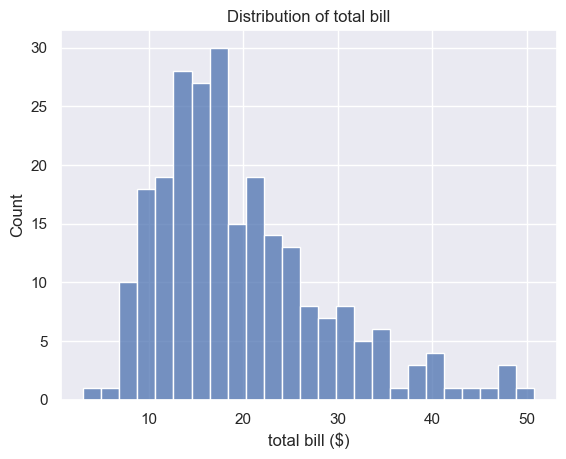

In [42]:
sns.histplot(data=tips, x="total_bill", bins=25)
plt.title("Distribution of total bill")
plt.xlabel("total bill ($)")
plt.show()
# read it like: most bills are 10-20$, long tail to the right (that skew again!)

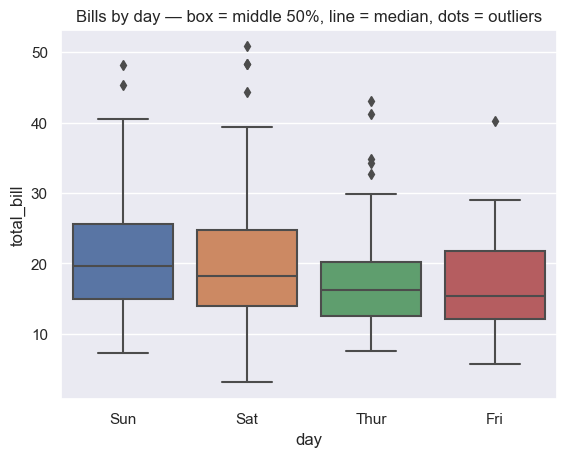

In [43]:
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Bills by day — box = middle 50%, line = median, dots = outliers")
plt.show()

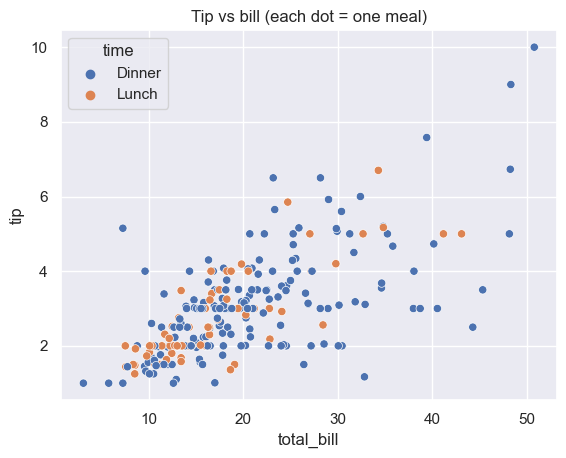

In [44]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Tip vs bill (each dot = one meal)")
plt.show()

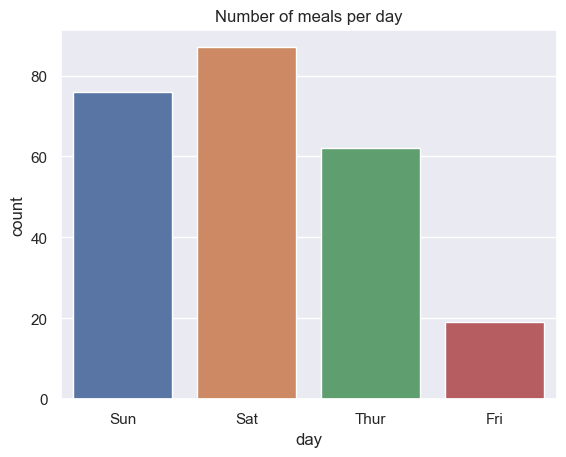

In [45]:
sns.countplot(data=tips, x="day")
plt.title("Number of meals per day")
plt.show()

c:\Users\omare\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


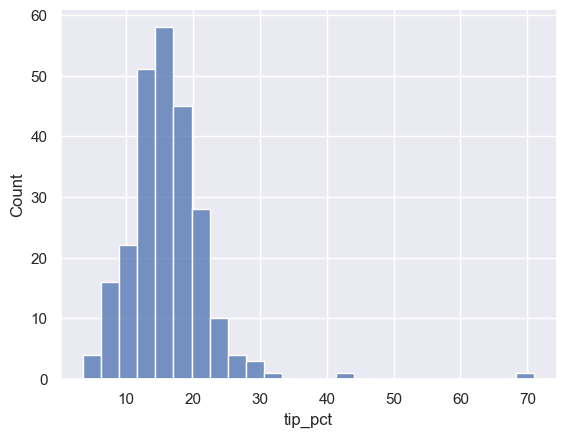

None


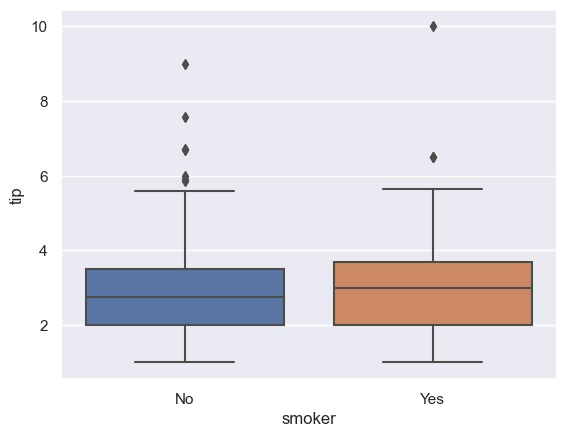

None


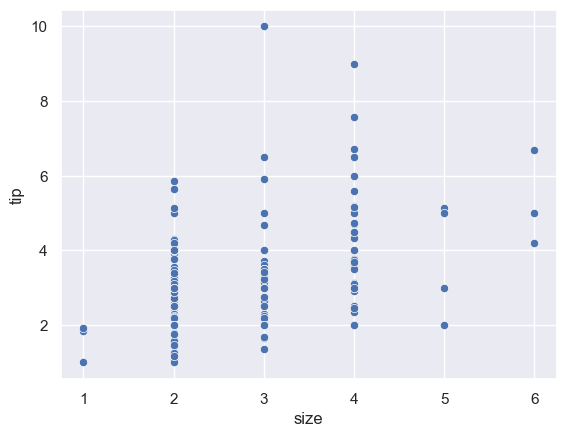

None


In [46]:
# ✏️ YOUR TURN — Exercise 9
# a) Histogram of tip_pct — where do most tips fall (as a %)?
# b) Boxplot of tip by smoker
# c) Scatter of size (x) vs tip (y)
# Give every chart a title!
sns.histplot(data=tips, x="tip_pct", bins=25)
print(plt.show())

sns.boxplot(data=tips, x="smoker", y="tip")
print(plt.show())

sns.scatterplot(data=tips, x="size", y="tip")
print(plt.show())

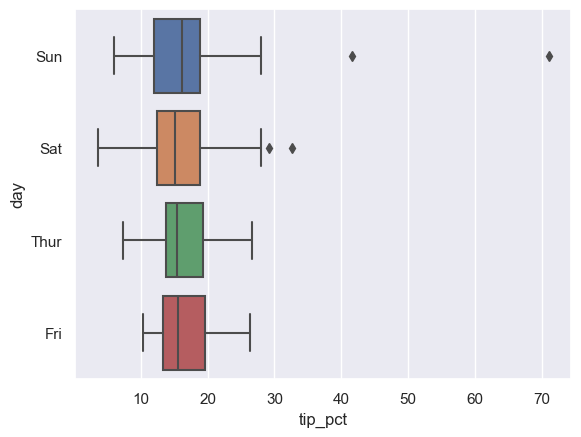

None


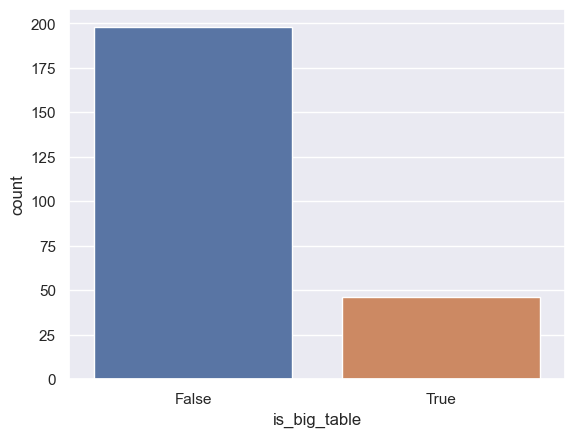

In [47]:
# ✏️ YOUR TURN — Exercise 9b
# d) Boxplot of tip_pct by day. Which day has the widest spread of tipping behaviour?
# e) Pick ONE of your charts and write, in a comment, the single sentence you would say
#    about it to the restaurant owner. (This is the skill, not the plotting.)

sns.boxplot(data=tips, x="tip_pct", y="day")
print(plt.show()) ##sunday

sns.countplot(data=tips, x="is_big_table")
plt.show()   #incerase small tables 

## 10. `groupby` — the analytics superpower 💪
Almost every business question is secretly: **"compute a statistic PER GROUP"**. Average bill *per day*. Churn rate *per contract type*. Sales *per region*.

The pattern (memorize it): `df.groupby("group_col")["value_col"].statistic()` — pandas **splits** the table into groups, **applies** the statistic to each, and **combines** the results.

In [48]:
tips.groupby("day")["total_bill"].mean().round(2)   # average bill per day

day
Fri     17.15
Sat     20.44
Sun     21.41
Thur    17.68
Name: total_bill, dtype: float64

In [49]:
# .agg() = several statistics at once
tips.groupby("day")["tip_pct"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
day,,,
Fri,16.99,15.56,19
Sat,15.32,15.18,87
Sun,16.69,16.11,76
Thur,16.13,15.38,62


In [50]:
# group by TWO columns
tips.groupby(["day", "time"])["total_bill"].mean().round(2)

day   time  
Fri   Dinner    19.66
      Lunch     12.85
Sat   Dinner    20.44
Sun   Dinner    21.41
Thur  Dinner    18.78
      Lunch     17.66
Name: total_bill, dtype: float64

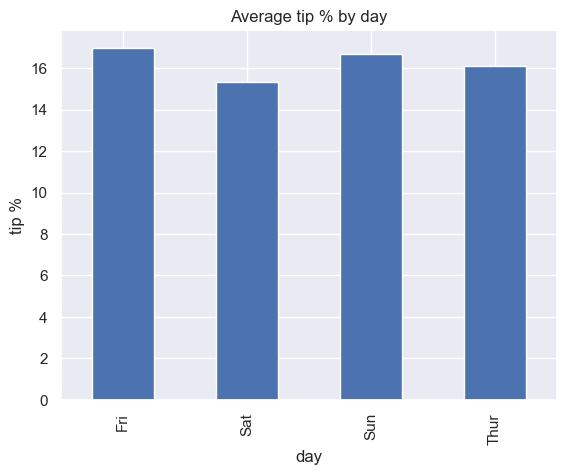

In [51]:
# groupby + plot = instant business chart
tips.groupby("day")["tip_pct"].mean().plot(kind="bar")
plt.title("Average tip % by day")
plt.ylabel("tip %")
plt.show()

In [52]:
# ✏️ YOUR TURN — Exercise 10
# a) Average tip_pct by smoker — do smoker tables tip a higher %?
# b) Average per_person spend by time (Lunch vs Dinner)
# c) For each day: the COUNT of meals and the MEAN total_bill in one table (use .agg)
print(tips.groupby("smoker")["tip_pct"].mean())

print(tips.groupby("time")["per_person"].mean())

print(tips.groupby("day")["total_bill"].agg(["count", "mean"]))


smoker
No     15.932846
Yes    16.319604
Name: tip_pct, dtype: float64
time
Dinner    8.109560
Lunch     7.315375
Name: per_person, dtype: float64
      count       mean
day                   
Fri      19  17.151579
Sat      87  20.441379
Sun      76  21.410000
Thur     62  17.682742


In [53]:
# # ✏️ YOUR TURN — Exercise 10b
# # d) For each day, compute BOTH the mean and the median tip_pct.
# #    Where do they differ most, and what does that tell you about that day? (comment)
# # e) Group by (sex, smoker) and show the average tip_pct for all four combinations.
print(tips.groupby("time")["tip_pct"].agg(["mean" , "median"]))
print("###############################")
tips.groupby(["sex" , "smoker"])["tip_pct"].mean()

             mean     median
time                        
Dinner  15.951779  15.540002
Lunch   16.412793  15.408357
###############################


sex     smoker
Female  No        15.692097
        Yes       18.215035
Male    No        16.066872
        Yes       15.277118
Name: tip_pct, dtype: float64

## 11. 🏆 Business questions — you're the analyst now
The restaurant owner asks you the questions below. For each one: **compute the number(s), show one chart, and write your answer in the markdown cell underneath, in plain English.**

Rules of the game:
- A number without a sentence is not an answer.
- If the data can't answer the question, say so and say what data you'd need — that is a valid, senior answer.
- Watch for mean-vs-median traps.

In [ ]:
# ✏️ Business Q1: Which day-time combination brings the highest AVERAGE bill?
#    Should the owner add staff to that shift? What does the COUNT of meals tell you
#    that the average alone doesn't?
tips.groupby(["day" , "time"])["total_bill"].mean()

#dinner snuday

day   time  
Fri   Dinner    19.663333
      Lunch     12.845714
Sat   Dinner    20.441379
Sun   Dinner    21.410000
Thur  Dinner    18.780000
      Lunch     17.664754
Name: total_bill, dtype: float64

✍️ **Your answer (Q1):**

*(write 2–3 sentences here)*

In [ ]:
# ✏️ Business Q2: Do bigger parties tip a LOWER percentage? Show evidence.
#    If yes, estimate how much tip % is lost per extra person at the table.
tips["size"].corr(tips["tip_pct"])
#yes negativley corr one inc second dec
...


-0.1428596006931235

✍️ **Your answer (Q2):**

*(write 2–3 sentences here)*

In [74]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size', 'tip_pct',
       'per_person', 'bill_with_tip', 'is_big_table'],
      dtype='object')

In [73]:
# ✏️ Business Q3: The owner wants to run a promo on the QUIETEST day.
#    Which day has the fewest meals, and what's the revenue (sum of total_bill) that day?
#    Careful: "fewest meals" and "fewest customers" are not the same column — check both.
tips.groupby("day")["total_bill"].count()
tips[tips["day"] == "Fri"]["total_bill"].sum()

325.88

✍️ **Your answer (Q3):**

*(write 2–3 sentences here)*

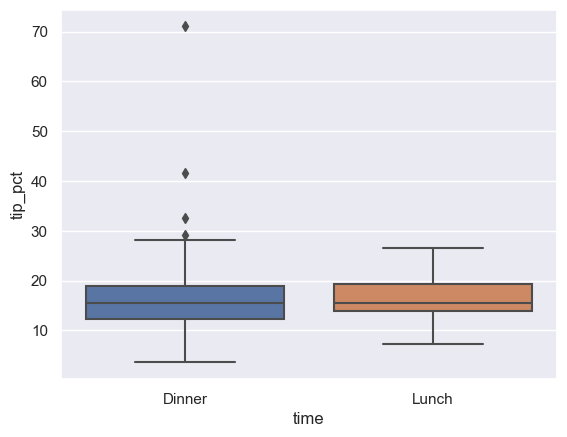

None


In [82]:
# ✏️ Business Q4: A waiter claims: "Dinner customers tip a higher PERCENTAGE than lunch customers."
#    True or false? Use numbers AND a chart. Report both the mean and the median — do they agree?
tips.groupby("time")["tip"].mean()
#true
sns.boxplot(data=tips, x="time", y="tip_pct")
print(plt.show())

✍️ **Your answer (Q4):**

*(write 2–3 sentences here)*

In [90]:
# ✏️ Business Q5: The owner is considering a "large party service charge" of 15% added
#    automatically for tables of 5+. Using the data, argue FOR or AGAINST it.
#    Show: how many meals it would affect, and what those tables currently tip on average.
tips[tips["size"] >= 5 ][["tip","tip_pct"]].agg(["mean","count"])

,tip,tip_pct
mean,4.56,14.804381
count,9.00,9.000000


✍️ **Your answer (Q5):**

*(write 2–3 sentences here)*

In [95]:
# ✏️ Business Q6: Marketing wants to target "high-value customers".
#    a) Propose a definition using the columns you have, and defend it in one sentence.
#    b) How many meals qualify under your definition?
#    c) What do these customers have in common (day/time/size/smoker)?
high_value = tips[tips["total_bill"] >= 30]
print(high_value["day"].value_counts(normalize=True))
print(high_value["time"].value_counts(normalize=True))
print(high_value["smoker"].value_counts(normalize=True))
print(high_value["size"].value_counts())

day
Sun     0.43750
Sat     0.37500
Thur    0.15625
Fri     0.03125
Name: proportion, dtype: float64
time
Dinner    0.84375
Lunch     0.15625
Name: proportion, dtype: float64
smoker
Yes    0.53125
No     0.46875
Name: proportion, dtype: float64
size
4    15
3     7
2     6
6     2
5     2
Name: count, dtype: int64


✍️ **Your answer (Q6):**

*(write 2–3 sentences here — including WHY you chose that definition)*

        total_bill       tip    tip_pct
smoker                                 
No       19.188278  2.991854  15.932846
Yes      20.756344  3.008710  16.319604

Table counts:
 smoker
No     151
Yes     93
Name: count, dtype: int64


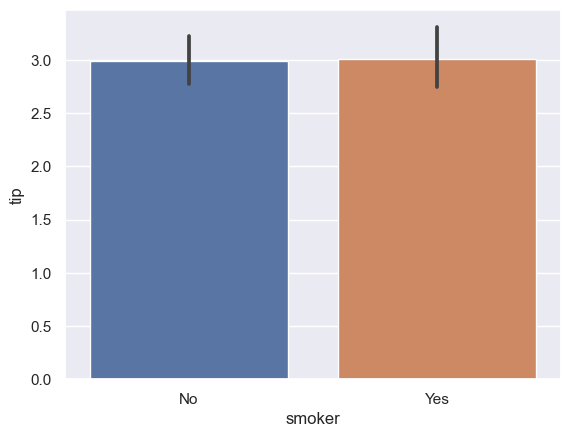

In [103]:
# ✏️ Business Q7 (the honest-analyst question):
#    The owner says: "This data proves smokers are better customers, let's add more smoking tables."
#    Check the claim with numbers — then explain in a comment what this dataset CANNOT tell us
#    about that decision (think: what's missing, and correlation vs causation).
sns.barplot(data=tips, x="smoker", y="tip")

# 1. Numbers Check:
print(tips.groupby("smoker")[["total_bill", "tip", "tip_pct"]].mean())
print("\nTable counts:\n", tips["smoker"].value_counts())

✍️ **Your answer (Q7):**

*(write 2–3 sentences here)*

## 12. 📋 Your cheat sheet (bookmark this cell!)
| Task | Code |
|---|---|
| load | `pd.read_csv(path_or_url)` |
| first look | `.head()` `.shape` `.info()` `.describe()` |
| select | `df["col"]`, `df[["a","b"]]` |
| filter | `df[(cond1) & (cond2)]`, `.isin([...])` |
| sort | `.sort_values("col", ascending=False)` |
| count categories | `.value_counts(normalize=True)` |
| new column | `df["new"] = ...` |
| fix text-numbers | `pd.to_numeric(col, errors="coerce")` |
| missing | `.isna().sum()`, `.fillna(x)`, `.dropna()` |
| stats | `.mean() .median() .std() .quantile(q) .corr(numeric_only=True)` |
| group stats | `df.groupby("g")["v"].mean()` / `.agg([...])` |
| charts | `sns.histplot / boxplot / scatterplot / countplot` |

**The three ideas to carry into Lab 2:**
1. The mean lies when data is skewed — check the median.
2. The mean of a 0/1 column is a **rate**.
3. `groupby(category)[target].mean()` answers most business questions.